In [12]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from tqdm import tqdm

import matplotlib.pyplot as plt

import yaml
from pathlib import Path

from thesis_project.datasets import SpeechCommandsGoogle
from thesis_project.utils.paths import get_data_dir

from thesis_project.models.architectures.keyword_spotting import KeyWordSpottingModel, KeyWordSpottingConfig, SpectrogramConfig, BackboneConfig, NoiseConfig

In [13]:
SKIP_TRAINING = True

In [14]:

# --- Load YAML file ---
config_path = Path("/Users/christoffer/Documents/Thesis/thesis_project/src/thesis_project/models/architectures/keyword_spotting/keyword_spotting_config.yaml")
with open(config_path, "r") as f:
    raw_cfg = yaml.safe_load(f)

# --- Parse and validate with Pydantic ---
cfg = KeyWordSpottingConfig(
    spectrogram=SpectrogramConfig(**raw_cfg["spectrogram"]),
    backbone=BackboneConfig(**raw_cfg["backbone"]),
    noise=NoiseConfig(), # just use default values which is no noise
    num_classes=raw_cfg.get("num_classes", 35),
)
model = KeyWordSpottingModel(cfg)
data_dir = get_data_dir()
train_set = SpeechCommandsGoogle(root=str(data_dir), subset="training", download=True)
val_set = SpeechCommandsGoogle(root=str(data_dir), subset="validation", download=True)

In [15]:
# Training configuration
batch_size = 32
num_epochs = 10
learning_rate = 0.001

# Device selection: CUDA > MPS > CPU
if torch.cuda.is_available():
    device = torch.device("cuda")
    print("Using CUDA")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Using MPS")
else:
    device = torch.device("cpu")
    print("Using CPU")

# Create data loaders (no num_workers for MPS compatibility)
train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_set, batch_size=batch_size, shuffle=False)

# Move model to device
model = model.to(device)

# Loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)


Using MPS


In [ ]:
if not SKIP_TRAINING:
    # Training loop
    for epoch in range(num_epochs):
        # Training phase
        model.train()
        train_loss = 0.0
        train_correct = 0
        train_total = 0
        
        train_pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Train]")
        for waveforms, labels, _ in train_pbar:  # Dataset returns (waveform, label, metadata)
            waveforms, labels = waveforms.to(device), labels.to(device)
            
            # Forward pass
            optimizer.zero_grad()
            logits = model(waveforms)
            loss = criterion(logits, labels)
            
            # Backward pass and optimization
            loss.backward()
            optimizer.step()
            
            # Statistics
            train_loss += loss.item() * waveforms.size(0)
            _, predicted = torch.max(logits, 1)
            train_total += labels.size(0)
            train_correct += (predicted == labels).sum().item()
            
            # Update progress bar
            train_pbar.set_postfix({
                'loss': f'{loss.item():.4f}',
                'acc': f'{100 * train_correct / train_total:.2f}%'
            })
        
        train_loss = train_loss / len(train_set)
        train_acc = 100 * train_correct / train_total
        
        # Validation phase
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0
        
        with torch.no_grad():
            val_pbar = tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Val]")
            for waveforms, labels, _ in val_pbar:  # Dataset returns (waveform, label, metadata)
                waveforms, labels = waveforms.to(device), labels.to(device)
                
                # Forward pass
                logits = model(waveforms)
                loss = criterion(logits, labels)
                
                # Statistics
                val_loss += loss.item() * waveforms.size(0)
                _, predicted = torch.max(logits, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()
                
                # Update progress bar
                val_pbar.set_postfix({
                    'loss': f'{loss.item():.4f}',
                    'acc': f'{100 * val_correct / val_total:.2f}%'
                })
        
        val_loss = val_loss / len(val_set)
        val_acc = 100 * val_correct / val_total
        
        # Print epoch summary
        print(f"\nEpoch {epoch+1}/{num_epochs} Summary:")
        print(f"  Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%")
        print(f"  Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")
        print("-" * 60)

    print("Training completed!")
    # save the model
    torch.save(model.state_dict(), "keyword_spotting_model_no_noise.pth")

In [ ]:
# load the model
model.load_state_dict(torch.load("keyword_spotting_model_no_noise.pth"))

<All keys matched successfully>

In [18]:
def validate_model(model, val_loader, criterion, device):
    # Validation phase
    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0
    
    with torch.no_grad():
        val_pbar = tqdm(val_loader, desc="Validation")
        for waveforms, labels, _ in val_pbar:  # Dataset returns (waveform, label, metadata)
            waveforms, labels = waveforms.to(device), labels.to(device)
            
            # Forward pass
            logits = model(waveforms)
            loss = criterion(logits, labels)
            
            # Statistics
            val_loss += loss.item() * waveforms.size(0)
            _, predicted = torch.max(logits, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()
            
            # Update progress bar
            val_pbar.set_postfix({
                'loss': f'{loss.item():.4f}',
                'acc': f'{100 * val_correct / val_total:.2f}%'
            })
    
    val_loss = val_loss / len(val_set)
    val_acc = 100 * val_correct / val_total

    return val_loss, val_acc

In [19]:
# validate the model after training
val_loss, val_acc = validate_model(model, val_loader, criterion, device)
print(f"Final Validation Loss: {val_loss:.4f}, Final Validation Acc: {val_acc:.2f}%")

Validation: 100%|██████████| 312/312 [00:06<00:00, 51.16it/s, loss=1.4509, acc=85.45%]

Final Validation Loss: 0.7421, Final Validation Acc: 85.45%


In [20]:
from thesis_project.models.blocks import CPC_Conv1d
compressible_layers = []
for name, layer in model.named_modules():
    if isinstance(layer, CPC_Conv1d):
        W = layer.weight_full.squeeze(-1)
        max_rank = min(W.shape)
        print(f"{name}: max_rank = {max_rank}")
        compressible_layers.append((name, layer))

backbone.0.0.cpw_conv1: max_rank = 128
backbone.0.0.cpw_conv2: max_rank = 128
backbone.0.1.cpw_conv1: max_rank = 128
backbone.0.1.cpw_conv2: max_rank = 128
backbone.0.2.cpw_conv1: max_rank = 128
backbone.0.2.cpw_conv2: max_rank = 128
frontend: max_rank = 128


In [21]:
def evaluate_rank_sweep(
    model,
    compressible_layers,
    validate_fn,
    val_loader,
    criterion,
    device,
    max_rank,
    step=4,
    compress_frontend=False,
    verbose=True,
):
    """
    Sweep across target ranks for CPC_Conv1d layers and record validation accuracy.

    Args:
        model (nn.Module): Your model containing CPC_Conv1d layers.
        compressible_layers (list[tuple[str, nn.Module]]): (name, layer) pairs of CPC_Conv1d layers.
        validate_fn (callable): Validation function (model, val_loader, criterion, device) -> (val_loss, val_acc)
        val_loader (DataLoader): Validation dataloader.
        criterion (nn.Module): Loss function.
        device (torch.device): Torch device.
        max_rank (int): Maximum rank (usually = in_channels = out_channels).
        step (int, optional): Step size for the rank sweep. Default = 4.
        compress_frontend (bool, optional): If False, skip compressing the "frontend" layer.
        verbose (bool, optional): Print progress messages.

    Returns:
        list[tuple[int, float]]: List of (target_rank, val_acc) results.
    """
    val_acc_results = []

    for target_rank in range(step, max_rank + 1, step):
        # --- Activate low-rank ---
        for name, layer in compressible_layers:
            if (not compress_frontend) and (name == "frontend"):
                continue
            layer.activate_low_rank(rank=target_rank)

        # --- Validate ---
        val_loss, val_acc = validate_fn(model, val_loader, criterion, device)
        val_acc_results.append((target_rank, val_acc))

        if verbose:
            print(f"[Rank {target_rank:>3}] Val Acc: {val_acc:.3f}")

    return val_acc_results


In [22]:
results = {}

results["val_acc_results"] = evaluate_rank_sweep(
    model=model,
    compressible_layers=compressible_layers,
    validate_fn=validate_model,
    val_loader=val_loader,
    criterion=criterion,    
    device=device,
    max_rank=128,
    step=4,
    compress_frontend=False,
    verbose=True
)
results["val_acc_results_compressed_frontend"] = evaluate_rank_sweep(
    model=model,
    compressible_layers=compressible_layers,
    validate_fn=validate_model,
    val_loader=val_loader,
    criterion=criterion,    
    device=device,
    max_rank=128,
    step=4,
    compress_frontend=True,
    verbose=True
)

Validation: 100%|██████████| 312/312 [00:06<00:00, 48.02it/s, loss=14.8685, acc=9.31%] 


[Rank   4] Val Acc: 9.308


Validation: 100%|██████████| 312/312 [00:06<00:00, 47.60it/s, loss=10.1723, acc=31.03%]


[Rank   8] Val Acc: 31.029


Validation: 100%|██████████| 312/312 [00:06<00:00, 48.21it/s, loss=4.4769, acc=64.34%] 


...

[Rank 120] Val Acc: 85.573


Validation: 100%|██████████| 312/312 [00:05<00:00, 53.52it/s, loss=1.5224, acc=85.58%]


[Rank 124] Val Acc: 85.583


Validation: 100%|██████████| 312/312 [00:05<00:00, 54.23it/s, loss=1.4509, acc=85.45%]

[Rank 128] Val Acc: 85.452


In [23]:
def plot_rank_vs_accuracy(val_acc_results, title=None, save_path=None):
    """
    Plot validation accuracy vs. target rank with relative PW layer FLOPs on a secondary y-axis.

    Args:
        val_acc_results (list[tuple[int, float]]): List of (rank, accuracy) pairs.
        title (str, optional): Custom title for the plot. Defaults to a descriptive title.
        save_path (str, optional): If provided, saves the plot to this file path instead of showing it.

    Example:
        val_acc_results = [(8, 10), (16, 40), (32, 65), (64, 75), (128, 85)]
        plot_rank_vs_accuracy(val_acc_results)
    """
    # Unpack
    ranks, accuracies = zip(*val_acc_results)
    max_rank = max(ranks)
    C = max_rank  # since in=out=C for PW convs

    # Compute relative FLOPs
    flops_rel = [2 * r / C for r in ranks]  # = 1 when r = C/2

    # --- Plot ---
    fig, ax1 = plt.subplots(figsize=(10, 6))

    # Accuracy (left axis)
    ax1.plot(ranks, accuracies, marker='o', color='tab:blue', label='Validation Accuracy')
    ax1.set_xlabel('Target Rank')
    ax1.set_ylabel('Validation Accuracy (%)', color='tab:blue')
    ax1.tick_params(axis='y', labelcolor='tab:blue')
    ax1.axvline(x=C // 2, color='r', linestyle='--', label='Max Rank // 2')
    ax1.grid(True)

    # FLOPs (right axis)
    ax2 = ax1.twinx()
    ax2.plot(ranks, flops_rel, color='tab:orange', label='Relative PW FLOPs')
    ax2.set_ylabel('Relative PW FLOPs (vs full conv)', color='tab:orange')
    ax2.tick_params(axis='y', labelcolor='tab:orange')

    # Legends
    ax1.legend(loc='upper left')
    ax2.legend(loc='upper right')

    # Title
    if title is None:
        title = 'Validation Accuracy vs. Target Rank (with Relative PW FLOPs)'
    plt.title(title)

    # Save or show
    if save_path:
        plt.savefig(save_path, bbox_inches='tight', dpi=300)
        print(f"Plot saved to {save_path}")
    else:
        plt.show()

    plt.close(fig)


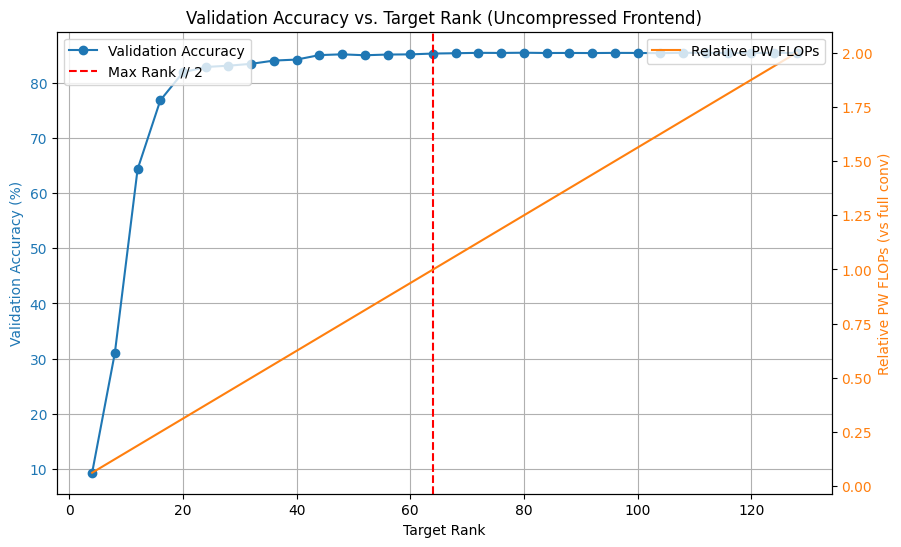

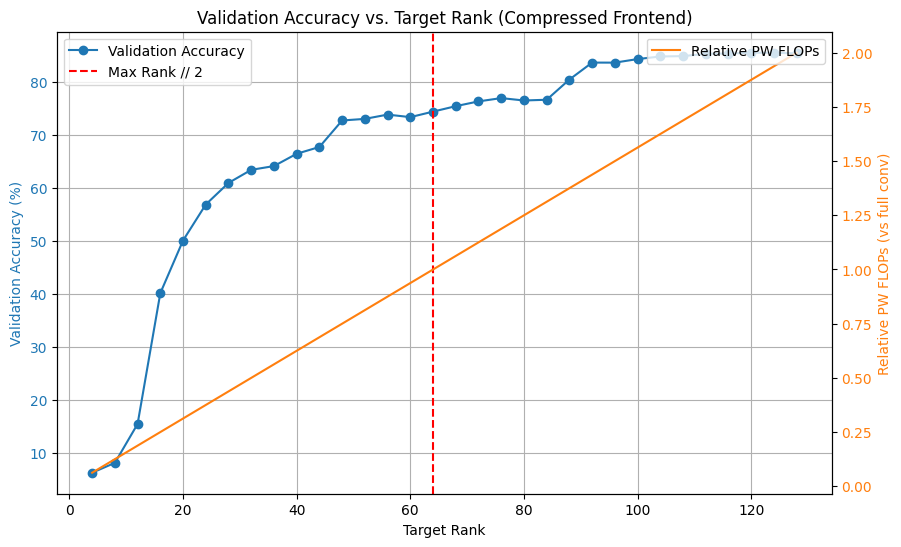

In [24]:
# view the results with and without compressing the frontend
plot_rank_vs_accuracy(results["val_acc_results"], title="Validation Accuracy vs. Target Rank (Uncompressed Frontend)")
plot_rank_vs_accuracy(results["val_acc_results_compressed_frontend"], title="Validation Accuracy vs. Target Rank (Compressed Frontend)")

In [25]:
# some final checks of model working as expected
# deactive the low-rank approximation again

for name, layer in compressible_layers:
    print(f"{name}: rank={layer.rank}, U={layer.U is not None}")
    layer.deactivate_low_rank()

# check that the deactivation worked by investigating the validation accuracy again
#val_loss, val_acc = validate_model(model, val_loader, criterion, device)

# set to rank 20
chosen_rank = 20
for name, layer in compressible_layers:
        layer.activate_low_rank(rank=chosen_rank)

for name, layer in compressible_layers:
    print(f"{name}: rank={layer.rank}, U={layer.U is not None}")

    W_full = layer.weight_full.detach().squeeze(-1)
    W_approx = (layer.U @ torch.diag(layer.S) @ layer.V).detach()
    error = torch.norm(W_full - W_approx) / torch.norm(W_full)
    print(f"Relative reconstruction error: {error.item():.4f}")
# test accuracy
val_loss, val_acc = validate_model(model, val_loader, criterion, device)
print(f"Validation Loss: {val_loss:.4f}, Validation Acc: {val_acc:.2f}%")


# see how the rank affects performance for different target ranks



backbone.0.0.cpw_conv1: rank=128, U=True
backbone.0.0.cpw_conv2: rank=128, U=True
backbone.0.1.cpw_conv1: rank=128, U=True
backbone.0.1.cpw_conv2: rank=128, U=True
backbone.0.2.cpw_conv1: rank=128, U=True
backbone.0.2.cpw_conv2: rank=128, U=True
frontend: rank=128, U=True
backbone.0.0.cpw_conv1: rank=20, U=True
Relative reconstruction error: 0.4609
backbone.0.0.cpw_conv2: rank=20, U=True
Relative reconstruction error: 0.4000
backbone.0.1.cpw_conv1: rank=20, U=True
Relative reconstruction error: 0.4885
backbone.0.1.cpw_conv2: rank=20, U=True
Relative reconstruction error: 0.3667
backbone.0.2.cpw_conv1: rank=20, U=True
Relative reconstruction error: 0.4961
backbone.0.2.cpw_conv2: rank=20, U=True
Relative reconstruction error: 0.1778
frontend: rank=20, U=True
Relative reconstruction error: 0.6557


Validation: 100%|██████████| 312/312 [00:05<00:00, 54.42it/s, loss=1.5905, acc=50.10%] 

Validation Loss: 2.7361, Validation Acc: 50.10%


In [26]:
def evaluate_energy_and_accuracy(model, compressible_layers, validate_fn, val_loader, criterion, device, chosen_rank=20):
    """
    Activates low-rank compression for all CPC_Conv1d layers,
    prints energy retained and reconstruction error for each layer,
    then evaluates validation performance.

    Args:
        model (nn.Module): Model containing CPC_Conv1d layers.
        compressible_layers (list[tuple[str, nn.Module]]): List of (name, layer) pairs.
        validate_fn (callable): Function (model, loader, criterion, device) -> (loss, acc).
        val_loader (DataLoader): Validation dataloader.
        criterion (nn.Module): Loss function.
        device (torch.device): Torch device.
        chosen_rank (int): Target rank to activate.

    Returns:
        dict: Summary of layer-wise retained energy and overall validation results.
    """
    print(f"\n=== Activating rank {chosen_rank} and computing energy retention ===\n")
    layer_stats = []

    for name, layer in compressible_layers:
        layer.activate_low_rank(rank=chosen_rank)

        # compute full SVD (for reference energy)
        W_full = layer.weight_full.detach().squeeze(-1)
        U_full, S_full, V_full = torch.linalg.svd(W_full, full_matrices=False)

        # energy retained by top-r singular values
        energy_retained = torch.sum(S_full[:chosen_rank] ** 2) / torch.sum(S_full ** 2)
        W_approx = (layer.U @ torch.diag(layer.S) @ layer.V).detach()
        error = torch.norm(W_full - W_approx) / torch.norm(W_full)

        print(f"{name:<35s} rank={chosen_rank:<3d}  energy={energy_retained.item():.4f}  error={error.item():.4f}")

        layer_stats.append({
            "name": name,
            "rank": chosen_rank,
            "energy_retained": energy_retained.item(),
            "reconstruction_error": error.item(),
        })

    # Evaluate validation accuracy
    val_loss, val_acc = validate_fn(model, val_loader, criterion, device)
    print(f"\nValidation Loss: {val_loss:.4f}, Validation Acc: {val_acc:.2f}%")

    return {
        "chosen_rank": chosen_rank,
        "layers": layer_stats,
        "val_loss": val_loss,
        "val_acc": val_acc,
    }


In [27]:
chosen_rank = 40
results = evaluate_energy_and_accuracy(
    model=model,
    compressible_layers=compressible_layers,
    validate_fn=validate_model,
    val_loader=val_loader,
    criterion=criterion,
    device=device,
    chosen_rank=chosen_rank
)


=== Activating rank 40 and computing energy retention ===

backbone.0.0.cpw_conv1              rank=40   energy=0.9194  error=0.2839
backbone.0.0.cpw_conv2              rank=40   energy=0.9556  error=0.2108
backbone.0.1.cpw_conv1              rank=40   energy=0.9150  error=0.2915
backbone.0.1.cpw_conv2              rank=40   energy=0.9689  error=0.1763
backbone.0.2.cpw_conv1              rank=40   energy=0.9195  error=0.2838
backbone.0.2.cpw_conv2              rank=40   energy=0.9934  error=0.0814
frontend                            rank=40   energy=0.7372  error=0.5127


Validation: 100%|██████████| 312/312 [00:05<00:00, 55.27it/s, loss=1.3024, acc=66.49%]


Validation Loss: 1.7733, Validation Acc: 66.49%
